In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("himanshunakrani/iris-dataset")

print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 0.98k/0.98k [00:00<00:00, 422kB/s]

Extracting files...
Path to dataset files: /Users/abdullahmahin/.cache/kagglehub/datasets/himanshunakrani/iris-dataset/versions/1


 Install Library


In [4]:
import pandas as pd
import numpy as np
from  matplotlib import pyplot as plt
import seaborn as sns


In [8]:
 

df = pd.read_csv(f"{path}/iris.csv")
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [9]:
df.info
df.value_counts()

sepal_length  sepal_width  petal_length  petal_width  species  
4.9           3.1          1.5           0.1          setosa       3
5.8           2.7          5.1           1.9          virginica    2
4.3           3.0          1.1           0.1          setosa       1
4.4           3.2          1.3           0.2          setosa       1
4.5           2.3          1.3           0.3          setosa       1
                                                                  ..
7.7           2.6          6.9           2.3          virginica    1
              2.8          6.7           2.0          virginica    1
              3.0          6.1           2.3          virginica    1
              3.8          6.7           2.2          virginica    1
7.9           3.8          6.4           2.0          virginica    1
Name: count, Length: 147, dtype: int64

In [11]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Target Mapping

In [12]:
df['target'] = df['species'].map({
    'setosa': 1,
    'virginica': 2,
    'versicolor': 3
})


In [17]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,target
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [18]:
df['target'].value_counts()


target
1    50
3    50
2    50
Name: count, dtype: int64

In [19]:
df['species'].unique()


array(['setosa', 'versicolor', 'virginica'], dtype=object)

ScatterPlot Visulization

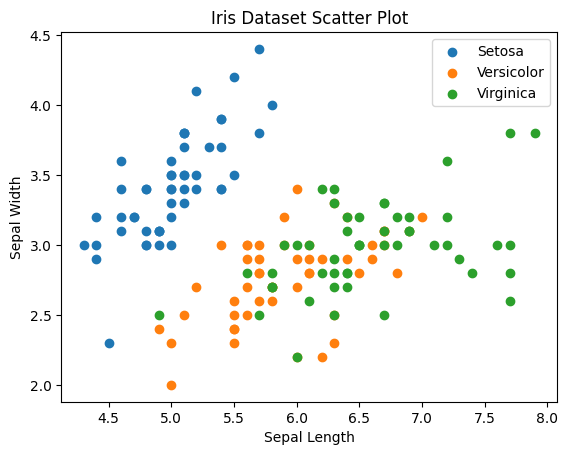

In [21]:
 
plt.scatter(
    df[df['species'] == 'setosa']['sepal_length'],
    df[df['species'] == 'setosa']['sepal_width'],
    label='Setosa'
)

 
plt.scatter(
    df[df['species'] == 'versicolor']['sepal_length'],
    df[df['species'] == 'versicolor']['sepal_width'],
    label='Versicolor'
)

 
plt.scatter(
    df[df['species'] == 'virginica']['sepal_length'],
    df[df['species'] == 'virginica']['sepal_width'],
    label='Virginica'
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Dataset Scatter Plot")
plt.legend()
plt.show()


Independent, Dependent

In [32]:
X = df.drop(columns=['target','species'])
Y = df['target']


 Train Test Split

In [33]:
from sklearn.model_selection import  train_test_split
x_train,x_test,y_train,y_test= train_test_split(X,Y,test_size=0.2,random_state=42)


In [34]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=200)
model.fit(x_train,y_train)

LogisticRegression(max_iter=200)

 Model Evaluation

In [37]:
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [38]:
from sklearn.metrics import  classification_report,confusion_matrix
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00         9

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [45]:
y_test 

73     3
18     1
118    2
78     3
76     3
31     1
64     3
141    2
68     3
82     3
110    2
12     1
36     1
9      1
19     1
56     3
104    2
69     3
55     3
132    2
29     1
127    2
26     1
128    2
131    2
145    2
108    2
143    2
45     1
30     1
Name: target, dtype: int64

In [46]:
y_pred

array([3, 1, 2, 3, 3, 1, 3, 2, 3, 3, 2, 1, 1, 1, 1, 3, 2, 3, 3, 2, 1, 2,
       1, 2, 2, 2, 2, 2, 1, 1])

Confusion Matrix Visulization

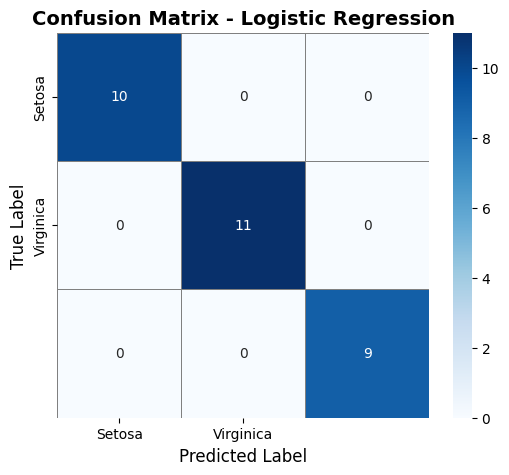

In [41]:
 
from sklearn.metrics import confusion_matrix

 
cm = confusion_matrix(y_test, y_pred)

 
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Setosa', 'Virginica'], 
            yticklabels=['Setosa', 'Virginica'],
            linewidths=0.5, linecolor='gray', cbar=True)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - Logistic Regression", fontsize=14, fontweight='bold')
plt.show()
